# Imports

In [9]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', '..', 'data')

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes

# Load data

## Load train/test/validation data

In [222]:
train_df = pd.read_pickle(os.path.join(data_path, "0_train_50.pkl"))
test_df = pd.read_pickle(os.path.join(data_path, "2_test_50.pkl"))

## Load blastp data

In [193]:
# BLAST results path
blast_results_path = os.path.join(data_path, 'proteins_human_50_test_vs_train_representatives_blastp_0.01.txt')

# Read BLAST results into a DataFrame
columns = ['query_gene', 'query_transcript', 'subject_gene', 'subject_transcript', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore', 'qseq', 'sseq']
df = pd.read_csv(blast_results_path, sep='[|\t]', engine='python', names=columns)

In [194]:
df

,query_gene,query_transcript,subject_gene,subject_transcript,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qseq,sseq
0,ENSG00000001461,ENST00000374399,ENSG00000104361,ENST00000430223,45.213,376,187,6,4,373,12,374,1.140000e-100,303.0,SHSAALKLQQLPPTSSSSAVSEASFS---YKEN---LIGALLAIFG...,SASAALDELSLNFTYGAPGAGNGSLSGDWYRRNQIHLFGVLLAILG...
1,ENSG00000001461,ENST00000374399,ENSG00000170113,ENST00000337435,24.913,289,204,4,35,320,30,308,8.110000e-17,79.7,IGALLAIFGHLVVSIALNLQKYCHIRLAGSKDPRAYFKTKTWWLGL...,LGLGVAVVSSLVNGSTFVLQKKGIVR--AKRRGTSYLTDIVWWAGT...
2,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,34.046,655,390,6,1,644,8,631,1.180000e-124,421.0,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,VKPNPLQDANLCSRVFFWWLNPLFKIGHKRRLEEDDMYSVLPEDRS...
3,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,37.113,582,342,4,865,1441,711,1273,3.150000e-115,394.0,WCLVIFLAEVAASLVVLWLLGNTPLQDKGNSTHSRN---NSYAVII...,WIVFIFLILLNTAAQVAYVLQDWWLSYWANKQSMLNVTVNGGGNVT...
4,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,28.017,232,149,6,1205,1431,403,621,2.540000e-17,87.4,PSGGQ--MTVKDLTAKYTEGGNA-ILENISFSISPGQRVGLLGRTG...,PSDGKKMVHVQDFTAFWDKASETPTLQGLSFTVRPGELLAVVGPVG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157128,ENSG00000290263,ENST00000672725,ENSG00000130997,ENST00000382865,98.555,346,5,0,531,876,1,346,0.000000e+00,719.0,MENYEALVGFDLCNTPLSSVAQKIMSAMHSGDLVDSKTWGKSTETM...,MENYEALVGFDLCNTPLSSVAQKIMSAMHSGDLVDSKTWGKSTETM...
157129,ENSG00000290320,ENST00000704639,ENSG00000233822,ENST00000606613,36.893,103,59,2,11,110,1,100,1.220000e-12,59.7,FPKNKTELYFPVKKKHEWANSATGKKRRWRKKRRKEAYFSYMGKIL...,MPEPSKSAPAPKKGSKKAVTKAQKKDGKKRKRSRKESYSVYVYKVL...
157130,ENSG00000291309,ENST00000706920,ENSG00000176956,ENST00000414417,36.232,138,73,4,6,132,26,159,8.450000e-07,44.7,AMKTLSLVLLVALLSMERAQGLRCYRCLAVLEGASCSVVSCPFLDG...,AMKGLGLALLAVLLCSAPAHGLWCQDCTLTTNSSHCTPKQCQPSDT...
157131,ENSG00000291309,ENST00000706920,ENSG00000261667,ENST00000562505,29.204,113,73,4,9,116,10,120,5.760000e-04,36.6,TLSLVLLVALLSMERAQGLRCYRCLAVLEGASCSVVSCPFLDGVCV...,TLPLAVASAGCATTPARNLSCYQCFKVSSWTECPPTWCSPLDQVCI...


## Add query length to BLASTP data

In [195]:
# Merge BLASTP data with test_df to add query length
df = df.merge(test_df[['transcript', 'length (aa)']], left_on='query_transcript', right_on='transcript', how='left')

# Rename the 'length (aa)' column to 'query_length'
df = df.rename(columns={'length (aa)': 'query_length'})

# Drop the redundant 'transcript' column
df = df.drop(columns=['transcript'])

# Display the updated DataFrame
df.head()

,query_gene,query_transcript,subject_gene,subject_transcript,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qseq,sseq,query_length
0,ENSG00000001461,ENST00000374399,ENSG00000104361,ENST00000430223,45.213,376,187,6,4,373,12,374,1.140000e-100,303.0,SHSAALKLQQLPPTSSSSAVSEASFS---YKEN---LIGALLAIFG...,SASAALDELSLNFTYGAPGAGNGSLSGDWYRRNQIHLFGVLLAILG...,406
1,ENSG00000001461,ENST00000374399,ENSG00000170113,ENST00000337435,24.913,289,204,4,35,320,30,308,8.110000e-17,79.7,IGALLAIFGHLVVSIALNLQKYCHIRLAGSKDPRAYFKTKTWWLGL...,LGLGVAVVSSLVNGSTFVLQKKGIVR--AKRRGTSYLTDIVWWAGT...,406
2,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,34.046,655,390,6,1,644,8,631,1.180000e-124,421.0,MQRSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSA...,VKPNPLQDANLCSRVFFWWLNPLFKIGHKRRLEEDDMYSVLPEDRS...,1480
3,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,37.113,582,342,4,865,1441,711,1273,3.150000e-115,394.0,WCLVIFLAEVAASLVVLWLLGNTPLQDKGNSTHSRN---NSYAVII...,WIVFIFLILLNTAAQVAYVLQDWWLSYWANKQSMLNVTVNGGGNVT...,1480
4,ENSG00000001626,ENST00000003084,ENSG00000125257,ENST00000645237,28.017,232,149,6,1205,1431,403,621,2.540000e-17,87.4,PSGGQ--MTVKDLTAKYTEGGNA-ILENISFSISPGQRVGLLGRTG...,PSDGKKMVHVQDFTAFWDKASETPTLQGLSFTVRPGELLAVVGPVG...,1480


# Find nearest trainset neighbours

In [203]:
# Example dataset
example_data = {
    'query_gene': ['ENSG000001', 'ENSG000001'],
    'query_transcript': ['ENST000001', 'ENST000001'],
    'subject_gene': ['ENSG000002', 'ENSG000002'],
    'subject_transcript': ['ENST000002', 'ENST000002'],
    'pident': [100, 100],
    'length': [2, 2],
    'mismatch': [0, 0],
    'gapopen': [0, 0],
    'qstart': [1, 4],
    'qend': [2, 5],
    'sstart': [2, 3],
    'send': [3, 4],
    'evalue': [0.0, 0.0],
    'bitscore': [50, 50],
    'qseq': ['AA', 'AA'],
    'sseq': ['BB', 'BB'],
    'query_length': [6, 6]
}

# Create DataFrame
example_df = pd.DataFrame(example_data)

# Display the example DataFrame
example_df

,query_gene,query_transcript,subject_gene,subject_transcript,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,qseq,sseq,query_length
0,ENSG000001,ENST000001,ENSG000002,ENST000002,100,2,0,0,1,2,2,3,0.0,50,AA,BB,6
1,ENSG000001,ENST000001,ENSG000002,ENST000002,100,2,0,0,4,5,3,4,0.0,50,AA,BB,6


In [219]:
# Find Nearest Trainset Neighbors using BLASTP results

# Group by query_transcript and subject_transcript
grouped = df.groupby(['query_transcript', 'subject_transcript'])

# Calculate the average pident over qseq length
def calculate_average_pident(group):
    query_length = group['query_length'].iloc[0]

    # Create a boolean mask for each position in qseq (qstart/qend begin with index 1)
    positions = np.arange(1, query_length + 1)
    mask = np.zeros((len(group), query_length), dtype=bool)
    mask[np.arange(len(group))[:, None], np.arange(query_length)] = (
        (positions >= group['qstart'].values[:, None]) & 
        (positions <= group['qend'].values[:, None])
    )

    # Create a 2D array of pident values
    pidents_array = np.tile(group['pident'].values[:, None], (1, query_length))

    # Apply the mask to zero out values outside the qstart/qend range
    masked_pidents_array = np.where(mask, pidents_array, 0)

    # Take the maximum of each column (position) in the masked array
    max_pidents = masked_pidents_array.max(axis=0)

    # Calculate the average pident
    return np.mean(max_pidents) if max_pidents.size > 0 else float('nan')

# Apply the function to each group
average_pidents = grouped.apply(calculate_average_pident, include_groups=False).reset_index(name='average_pident')

# Find nearest trainset neighbor for each query
# nearest_trainset_neighbors = average_pidents.loc[average_pidents.groupby('query_transcript')['average_pident'].idxmax()]
average_pidents


,query_transcript,subject_transcript,average_pident
0,ENST000001,ENST000002,66.666667


# Save nearest neighbours

In [ ]:
# Save closest neighbors to a file
nearest_trainset_neighbors_path = os.path.join('.', 'proteins_human_50_testset_nearest_trainset_representatives_0.01.pkl')

nearest_trainset_neighbors.to_pickle(nearest_trainset_neighbors_path)

# Load, Process and Merge Nearest Neighbours

## Load nearest neighbours

In [250]:
# Load the nearest neighbors data from the pickle file

nearest_trainset_neighbors_path = os.path.join(data_path, 'proteins_human_50_testset_nearest_trainset_representatives_0.01.pkl')

nearest_trainset_neighbors = pd.read_pickle(nearest_trainset_neighbors_path)

In [251]:
nearest_trainset_neighbors

,query_transcript,subject_transcript,average_pident
1,ENST00000002596,ENST00000312719,44.108717
26,ENST00000003084,ENST00000645237,29.283666
34,ENST00000003912,ENST00000430223,40.431935
39,ENST00000004982,ENST00000650687,43.616400
173,ENST00000005082,ENST00000377179,46.214157
...,...,...,...
356585,ENST00000707113,ENST00000397332,32.002624
356595,ENST00000707114,ENST00000397332,32.002624
356605,ENST00000707115,ENST00000397332,32.002624
356615,ENST00000707116,ENST00000397332,32.002624


## Add missing transcripts and merge with test

In [ ]:
# Add missing query transcripts to the DataFrame
test_df = test_df.rename(columns={'gene':'query_gene', 'transcript': 'query_transcript'})
missing_transcripts = test_df[~test_df['query_transcript'].isin(nearest_trainset_neighbors['query_transcript'])]
missing_transcripts = missing_transcripts[['query_gene', 'query_transcript']]
df = pd.concat([nearest_trainset_neighbors, missing_transcripts], ignore_index=True)

# Fill missing pident values with 0
df['average_pident'] = df['average_pident'].fillna(0)

# Merge the DataFrame with the test DataFrame
merged_test = test_df.merge(df, on='query_transcript', how='left')
merged_test = merged_test.drop(columns=['query_gene_y', 'gene', 'transcript']).rename(columns={'query_gene_x': 'query_gene'})

In [253]:
merged_test

,cluster,length (aa),query_gene,query_transcript,seq,amino_acid_seq,median,subject_transcript,average_pident
0,2191,932,ENSG00000134324,ENST00000396097,ATGAGCAGAGTGCAGACCATGAATTACGTGGGGCAGTTAGCCGGCC...,MSRVQTMNYVGQLAGQVFVTVKELYKGLNPATLSGCIDIIVIRQPN...,"(expr_pre75_90, expr_pre50_75, expr_pre75_90, ...",ENST00000261596,48.943442
1,5329,249,ENSG00000172456,ENST00000634606,ATGTGGCTGGACCATCGAGCAGTCAGTCAAGTTAACAGGATCAATG...,MWLDHRAVSQVNRINETKHSVLQYVGGVMSVEMQAPKLLWLKENLR...,"(expr_pre25_50, expr_pre25_50, expr_pre25_50, ...",NaN,0.000000
2,7096,463,ENSG00000118495,ENST00000416623,ATGGCCACGTTCCCCTGCCAGTTATGTGGCAAGACGTTCCTCACCC...,MATFPCQLCGKTFLTLEKFTIHNYSHSRERPYKCVQPDCGKAFVSR...,"(expr_pre25_50, expr_pre50_75, expr_pre50_75, ...",ENST00000367405,18.618728
3,7405,432,ENSG00000257950,ENST00000550383,ATGGGGCAGGCGGGCTGCAAGGGGCTCTGCCTGTCGCTGTTCGACT...,MGQAGCKGLCLSLFDYKTEKYVIAKNKKVGLLYRLLQASILAYLVV...,NaN,ENST00000413302,38.319426
4,5500,57,ENSG00000107669,ENST00000690706,ATGGCTTTCTGGGCGGGGGGTTCGCCCAGCGTCGTGGACTATTTCC...,MAFWAGGSPSVVDYFPSEDFYRCGYCKNESGSRSNGMWAHSMTVQD...,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...
15971,3560,726,ENSG00000081277,ENST00000367324,ATGAACCACTCGCCGCTCAAGACCGCCTTGGCGTACGAATGCTTCC...,MNHSPLKTALAYECFQDQDNSTLALPSDQKMKTGTSGRQRVQEQVM...,"(expr_pre75_90, expr_pre75_90, expr_pre25_50, ...",ENST00000331563,23.066762
15972,3464,758,ENSG00000105298,ENST00000429344,ATGGGTCGGGACACACGCTCGCGCTCGCGGTCCGCGGGTCGCCGGG...,MGRDTRSRSRSAGRRGRRRQSQSGSRSRSRSHGRRNRRRREDEGRR...,"(expr_pre75_90, expr_pre75_90, expr_pre75_90, ...",NaN,0.000000
15973,2613,153,ENSG00000066468,ENST00000683035,ATGGTCAGCTGGGGTCGTTTCATCTGCCTGGTCGTGGTCACCATGG...,MVSWGRFICLVVVTMATLSLARPSFSLVEDTTLEPEEPPTKYQISQ...,NaN,ENST00000393637,21.568418
15974,530,61,ENSG00000197892,ENST00000522355,ATGGGGGACTCCAAAGTGAAAGTGGCGGTGCGGATACGACCCATGA...,MGDSKVKVAVRIRPMNRRETDLHTKCVVDVDANKVILNPVNTNLSK...,"(expr_low25, expr_low25, expr_pre25_50, expr_l...",ENST00000635823,32.786557


# Save Merged Test Pickle

In [267]:
# Save merged_test DataFrame to a pickle file
merged_test_path = os.path.join(data_path, '2_test_50_nn.pkl')
merged_test.to_pickle(merged_test_path)

# Visualize Nearest Neighbours Data

In [2]:
merged_test_path = os.path.join(data_path, '2_test_50_nn.pkl')
merged_test = pd.read_pickle(merged_test_path)

In [276]:
non_zero_count = len(merged_test[merged_test['average_pident'] != 0])
print(f"Amount of non-zero pident values: {non_zero_count}")
print(f"Percentage of non-zero pident values: {non_zero_count / len(merged_test) * 100:.2f}%")

Amount of non-zero pident values: 10586
Percentage of non-zero pident values: 66.26%


In [277]:
zero_count = (merged_test['average_pident'] == 0).sum()
print(f"Number of 0 in 'pident' column: {zero_count}")
print(f"Percentage of 0 in 'pident' column: {zero_count / len(merged_test) * 100:.2f}%")

Number of 0 in 'pident' column: 5390
Percentage of 0 in 'pident' column: 33.74%


In [256]:
lowest_non_zero_pident = merged_test[merged_test['average_pident'] > 0]['average_pident'].min()
print(f"Lowest value higher than 0 in 'pident' column: {lowest_non_zero_pident}")

highest_pident = merged_test['average_pident'].max()
print(f"Highest value in 'pident' column: {highest_pident}")

Lowest value higher than 0 in 'pident' column: 0.4743893011216566
Highest value in 'pident' column: 100.0


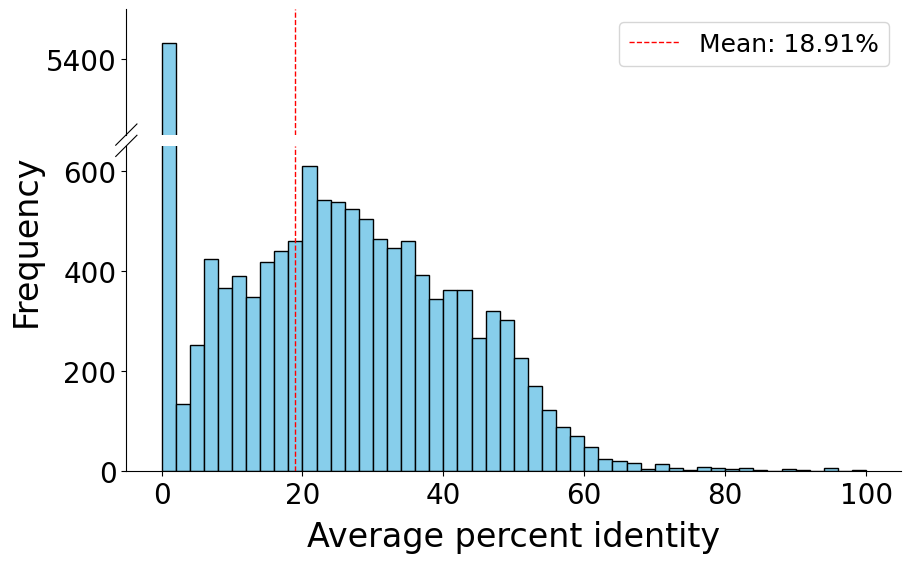

In [69]:
# Create a figure with a broken y-axis
fig = plt.figure(figsize=(10, 6))
bax = brokenaxes(ylims=((0, 650), (5250, 5500)), hspace=0.05)

# Plot the distribution of 'pident' column values
# bax.grid(True, linestyle='-', alpha=0.7)
bax.hist(merged_test['average_pident'], bins=50, color='skyblue', alpha=1, edgecolor='black')

# Calculate the mean of 'pident' column
mean_pident = merged_test['average_pident'].mean()

# Add a vertical line for the mean
bax.axvline(mean_pident, color='r', linestyle='--', linewidth=1, label=f'Mean: {mean_pident:.2f}%')

# bax.set_title('Average pident (%) distribution')
bax.set_xlabel('Average percent identity', fontsize=24, labelpad=35)
bax.set_ylabel('Frequency', fontsize=24, labelpad=60)
bax.tick_params(axis='x', labelsize=20)
bax.tick_params(axis='y', labelsize=20)
bax.legend(fontsize=18)

plt.savefig('average_pident_distribution.svg', format='svg', bbox_inches='tight')

plt.show()


In [273]:
# Filter rows where pident is 100
pident_100_rows = merged_test[merged_test['average_pident'] == 100]
pident_100_rows

,cluster,length (aa),query_gene,query_transcript,seq,amino_acid_seq,median,subject_transcript,average_pident
3728,4134,50,ENSG00000129559,ENST00000524927,ATGCTAATTAAAGTGAAGACGCTGACCGGAAAGGAGATTGAGATTG...,MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYS...,"(expr_pre50_75, expr_pre50_75, expr_pre75_90, ...",ENST00000605847,100.0
15071,4134,50,ENSG00000129559,ENST00000396828,ATGCTAATTAAAGTGAAGACGCTGACCGGAAAGGAGATTGAGATTG...,MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYS...,"(expr_pre75_90, expr_pre75_90, expr_pre75_90, ...",ENST00000605847,100.0


In [263]:
print(train_df[train_df['transcript'] == 'ENST00000605847']['amino_acid_seq'].values[0])
print(test_df[test_df['query_transcript'] == 'ENST00000524927']['amino_acid_seq'].values[0])

MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYSGKQMNDEKTAADYKILVMELYEIGGAKTSDCTQRCLRS*
MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYSGKQM*


In [ ]:
print(train_df[train_df['transcript'] == 'ENST00000605847']['amino_acid_seq'].values[0])
print(test_df[test_df['query_transcript'] == 'ENST00000396828']['amino_acid_seq'].values[0])

MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYSGKQMNDEKTAADYKILVMELYEIGGAKTSDCTQRCLRS*
MLIKVKTLTGKEIEIDIEPTDKVERIKERVEEKEGIPPQQQRLIYSGKQM*
